In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
from google.colab import files
uploaded=files.upload()


Saving HR_comma_sep.csv to HR_comma_sep.csv


In [7]:
df = pd.read_csv("HR_comma_sep.csv")

In [8]:
print(df.shape)

(14999, 10)


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None


In [10]:
print(df.head())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4              0     1                      0  sales   
3                   5              0     1                      0  sales   
4                   3              0     1                      0  sales   

   salary  
0     low  
1  medium  
2  medium  
3     low  
4 

In [11]:
print(df.isnull().sum())

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 3008


In [13]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (14999, 10)
After: (11991, 10)


In [14]:
df.rename(columns={
    "sales":"department",
    "left":"attrition"
}, inplace=True)

In [15]:
df["salary_band"] = df["salary"]

In [16]:
df["experience_group"] = pd.cut(
    df["time_spend_company"],
    bins=[0,2,5,10],
    labels=["Fresher","Mid-Level","Senior"]
)

In [17]:
conditions = [
    (df["satisfaction_level"] < 0.4) &
    (df["average_montly_hours"] > 200),

    (df["satisfaction_level"] < 0.6),

    (df["satisfaction_level"] >= 0.6)
]

choices = ["High Risk","Medium Risk","Low Risk"]

df["risk_category"] = np.select(
    conditions,
    choices,
    default="Low Risk"
)

print(df.head())


   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  attrition  promotion_last_5years  \
0                   3              0          1                      0   
1                   6              0          1                      0   
2                   4              0          1                      0   
3                   5              0          1                      0   
4                   3              0          1                      0   

  department  salary salary_band experience_group risk_category  
0      s

phase 2:KPI DESIGN

In [19]:
total_emp = len(df)

In [20]:
attrition_rate = (df["attrition"].mean()) * 100

In [21]:
retention_rate = 100 - attrition_rate

In [22]:
avg_tenure = df["time_spend_company"].mean()

In [23]:
job_satisfaction = df["satisfaction_level"].mean()

In [24]:
# Average Income by Salary Group
avg_income = df["salary_band"].value_counts()

In [25]:
overtime_pct = (
    (df["average_montly_hours"] > 200).sum()
    / len(df)
) * 100

In [26]:
high_risk = (
    df["risk_category"]=="High Risk"
).sum()

print("Total Employees:", total_emp)
print("Attrition Rate:", round(attrition_rate,2))
print("Retention Rate:", round(retention_rate,2))
print("Average Tenure:", round(avg_tenure,2))
print("Job Satisfaction:", round(job_satisfaction,2))
print("Overtime %:", round(overtime_pct,2))
print("High Risk Employees:", high_risk)

Total Employees: 11991
Attrition Rate: 16.6
Retention Rate: 83.4
Average Tenure: 3.36
Job Satisfaction: 0.63
Overtime %: 49.59
High Risk Employees: 1053


Phase 3:ANLYTICAL INVESTICATION


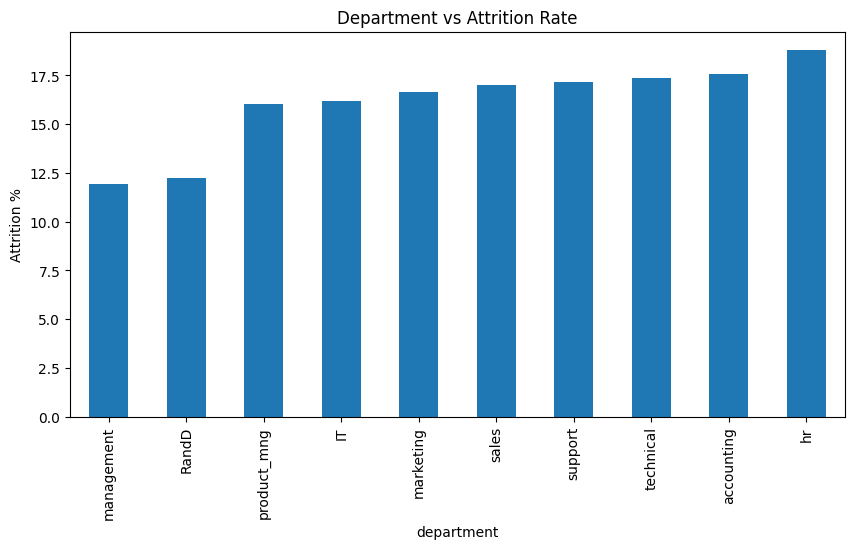

In [27]:
dept_attrition = df.groupby("department")["attrition"].mean()*100

plt.figure(figsize=(10,5))
dept_attrition.sort_values().plot(kind="bar")

plt.title("Department vs Attrition Rate")
plt.ylabel("Attrition %")
plt.show()

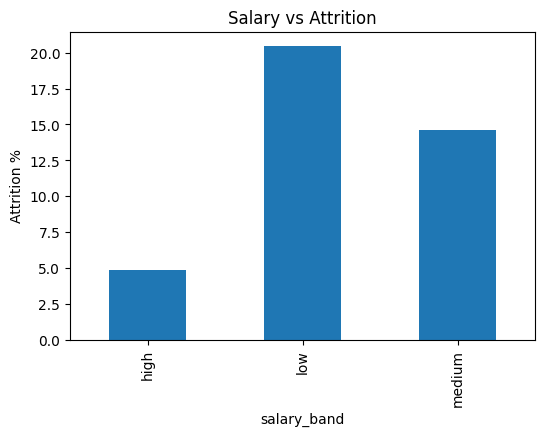

In [28]:
salary_attrition = df.groupby(
    "salary_band"
)["attrition"].mean()*100

salary_attrition.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Salary vs Attrition")
plt.ylabel("Attrition %")
plt.show()

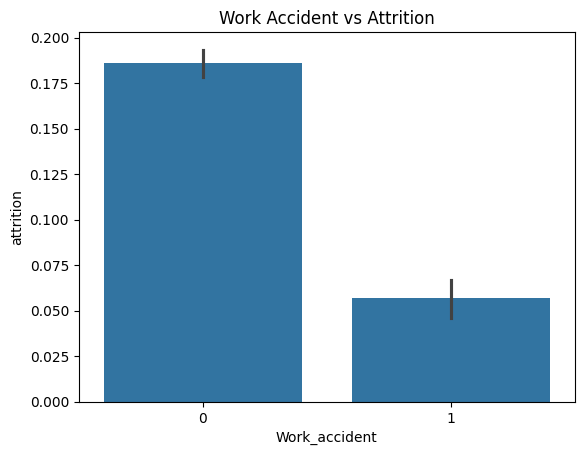

In [29]:
sns.barplot(
    data=df,
    x="Work_accident",
    y="attrition"
)

plt.title("Work Accident vs Attrition")
plt.show()

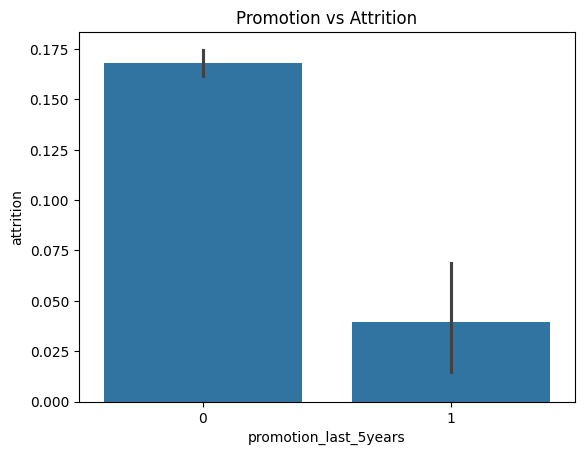

In [30]:
sns.barplot(
    data=df,
    x="promotion_last_5years",
    y="attrition"
)

plt.title("Promotion vs Attrition")
plt.show()

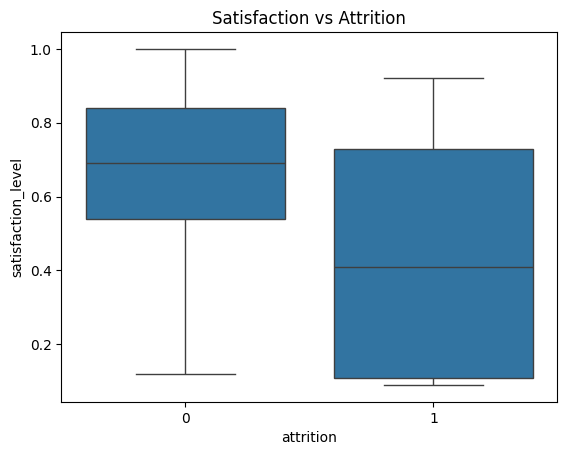

In [31]:
sns.boxplot(
    data=df,
    x="attrition",
    y="satisfaction_level"
)

plt.title("Satisfaction vs Attrition")
plt.show()

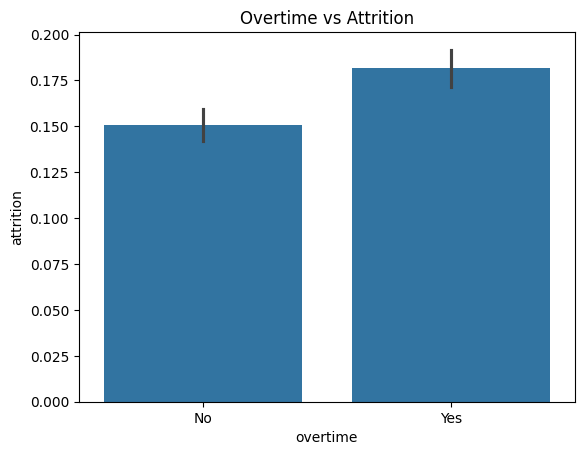

In [32]:
df["overtime"] = np.where(
    df["average_montly_hours"] > 200,
    "Yes",
    "No"
)

sns.barplot(
    data=df,
    x="overtime",
    y="attrition"
)

plt.title("Overtime vs Attrition")
plt.show()

correlation heatmap

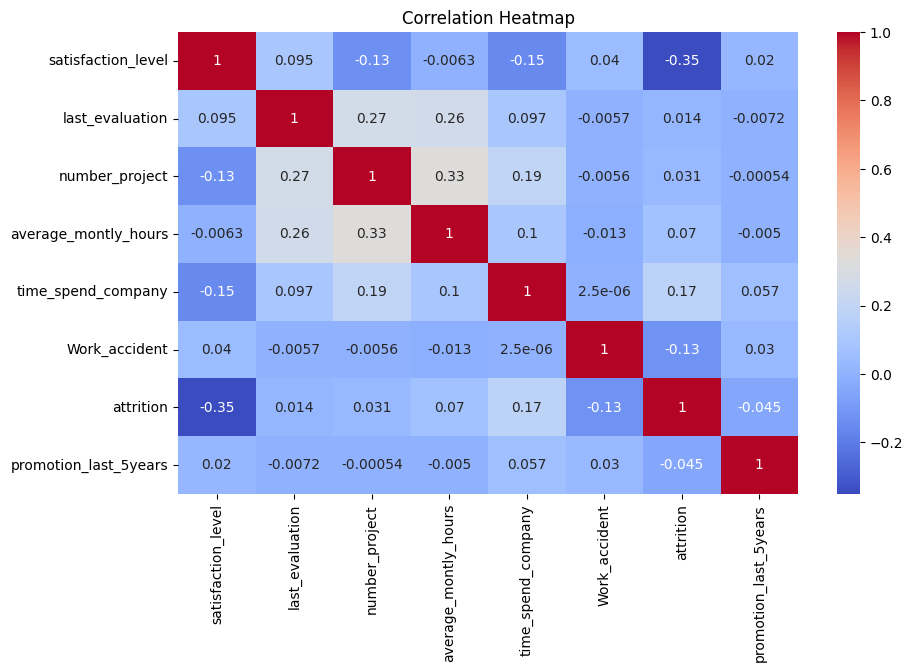

In [33]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Phase 4: Employees segmentation

High risk employees

In [34]:
high_risk = df[
    df["risk_category"]=="High Risk"
]

print(high_risk.shape)

(1053, 14)


Long term employees

In [35]:
long_term = df[
    df["time_spend_company"] >= 5
]

print(long_term.shape)

(1886, 14)


Overtime employees

In [36]:
overtime_emp = df[
    df["average_montly_hours"] > 200
]

print(overtime_emp.shape)

(5946, 14)


dissatisfied employees

In [37]:
dissatisfied = df[
    df["satisfaction_level"] < 0.5
]

print(dissatisfied.shape)

(3184, 14)


Segment camparision

In [38]:
segment_analysis = df.groupby(
    "risk_category"
).agg({
    "satisfaction_level":"mean",
    "average_montly_hours":"mean",
    "time_spend_company":"mean",
    "attrition":"mean"
})

print(segment_analysis)

               satisfaction_level  average_montly_hours  time_spend_company  \
risk_category                                                                 
High Risk                0.165451            258.668566            4.242165   
Low Risk                 0.795456            204.146595            3.276027   
Medium Risk              0.449585            177.656919            3.288512   

               attrition  
risk_category             
High Risk       0.506173  
Low Risk        0.077659  
Medium Risk     0.236554  


In [40]:
df.to_csv("cleaned_hr_analysis.csv", index=False)

In [41]:
from google.colab import files

files.download("cleaned_hr_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>